In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json

In [153]:
df = pd.read_csv("clean_data_products.csv", index_col=0)

In [154]:
df.isna().sum() 

code                             0
product_name                  1081
product_type                     6
brands                        2531
canonical_categories             0
canonical_countries              0
ingredients_n                    0
known_ingredients_n              0
unknown_ingredients_n            0
completeness                  2533
scans_n                       9646
unique_scans_n                9646
creator                         17
completeness_ratio               0
compl_critical_ratio             0
is_duplicate_product_name        0
ingredients_match                0
unknown_ingredients_ratio        0
ingredients_quality_score        0
countries_count                  0
categories_count                 0
missing_country_flag             0
missing_category_flag            0
missing_both_taxonomy_flag       0
country_languages                0
category_languages               0
countries_mixl                   0
categories_mixl                  0
has_lang_conflict   

### Llenando Missing data

In [155]:
df['scans_n'] = df['scans_n'].fillna(0)
df['unique_scans_n'] = df['unique_scans_n'].fillna(0)

In [156]:
df['completeness'].describe()

count    11991.000000
mean         0.563304
std          0.174861
min          0.075000
25%          0.462500
50%          0.566667
75%          0.683333
max          1.100000
Name: completeness, dtype: float64

In [158]:
df['completeness'] = df['completeness'].fillna(0)

In [159]:
df['creator'] = df['creator'].fillna("Unkown")

In [160]:
df['product_name'] = df['product_name'].fillna("No Product Name")

In [161]:
df['product_type'].unique()

<StringArray>
['beauty', nan]
Length: 2, dtype: str

In [162]:
# Como sabemos que todos los productos son del tipo beauty se eliminara esta columna
df = df.drop(["product_type"],axis=1)

In [163]:
df['brands'].nunique()

4686

In [165]:
print(df['brands'].value_counts().to_string())

brands
L'OREAL NORGE AS                                                                                                                   366
Cosmia                                                                                                                             293
Nivea                                                                                                                              226
Axe                                                                                                                                174
Unilever, Dove                                                                                                                     151
Deliplus                                                                                                                           127
Carrefour                                                                                                                          126
Unilever, Signal                                

In [167]:
# ── CAPA 1: GRUPOS CORPORATIVOS (fabricantes) ──────────────────────────────
# Si aparece este texto → esa es la empresa matriz
CORPORATE_GROUPS = {
    # Patrón regex → nombre canónico
    r"unilever":                    "Unilever",
    r"l['\-]?or[eé]al|loreal|lascad": "L'Oréal",
    r"henkel":                      "Henkel",
    r"beiersdorf":                  "Beiersdorf",
    r"colgate[\-\s]?palmolive|colgate palmolive": "Colgate-Palmolive",
    r"procter\s*&?\s*gamble|p\s*&\s*g\b": "Procter & Gamble",
    r"johnson\s*&?\s*johnson|jntl|johnson's baby": "Johnson & Johnson",
    r"reckitt":                     "Reckitt",
    r"haleon":                      "Haleon",
    r"henkel":                      "Henkel",
    r"shiseido":                    "Shiseido",
    r"coty\b":                      "Coty",
    r"orkla":                       "Orkla",
    r"gsk|glaxosmithkline":         "GSK/Haleon",
    r"yves\s+rocher":               "Yves Rocher",
    r"clarins":                     "Clarins",
    r"pierre\s+fabre":              "Pierre Fabre",
    r"bioderma":                    "Bioderma",
}

# ── CAPA 2: MARCAS PROPIAS DE RETAILERS ────────────────────────────────────
# Marca propia → retailer dueño
PRIVATE_LABELS = {
    r"cosmia|auchan\s*baby|auchan\s*bio|pouce|rik\s*&\s*rok": "Auchan (Cosmia)",
    r"balea|alverde|isana|denkmit|ebelin|sundance|sun\s*dance|seinz|ombia|profissimo": "dm Drogerie",
    r"\bcien\b|dentalux|dontodent|lacura|toujours|lupilu": "Lidl",
    r"deliplus|hacendado":          "Mercadona",
    r"marque\s+rep[eè]re|inell|manava|vitanove|nate[iï]s|dentamyl": "Leclerc",
    r"\blabell\b":                  "Intermarché",
    r"\bby\s+u\b|\bsyst[eè]me\s+u\b|\b\bu\b\s+nature": "Système U",
    r"leader\s+price|casino\b|monoprix\b": "Casino/Monoprix",
    r"carrefour":                   "Carrefour",
    r"\bkruidvat\b":                "Kruidvat",
    r"\bhema\b":                    "Hema",
    r"lacura|biocura":              "Aldi",
    r"\berkos\b|edeka\b":           "Edeka",
    r"\brossmann\b|isana\b|prokudent": "Rossmann (Isana)",
}

# ── CAPA 3: MARCAS INDEPENDIENTES TOP ─────────────────────────────────────
# Solo las que aparecen suficiente como para importar
TOP_INDEPENDENTS = {
    r"\bnivea\b":                   "Nivea (Beiersdorf)",
    r"\bdove\b":                    "Dove (Unilever)",
    r"\bgarnier\b":                 "Garnier (L'Oréal)",
    r"\bpantene\b|pantène":         "Pantene (P&G)",
    r"\bgillette\b":                "Gillette (P&G)",
    r"\bhead\s*&?\s*shoulders?\b|h&s\b": "Head & Shoulders (P&G)",
    r"\boral[\-\s]?b\b":            "Oral-B (P&G)",
    r"\bcolgate\b":                 "Colgate (Colgate-Palmolive)",
    r"\bpalmolive\b":               "Palmolive (Colgate-Palmolive)",
    r"\baxe\b|\blynx\b":            "Axe (Unilever)",
    r"\brexona\b":                  "Rexona (Unilever)",
    r"\bsignal\b":                  "Signal (Unilever)",
    r"\bsanex\b":                   "Sanex (Colgate-Palmolive)",
    r"\bneutrogena\b":              "Neutrogena (J&J)",
    r"\baveeno\b":                  "Aveeno (J&J)",
    r"\bschwarzko(?:pf|ph)\b":      "Schwarzkopf (Henkel)",
    r"\bpersil\b":                  "Persil (Henkel)",
    r"\bvichy\b":                   "Vichy (L'Oréal)",
    r"\bla\s+roche[\-\s]?posay\b":  "La Roche-Posay (L'Oréal)",
    r"\bcerave\b":                  "CeraVe (L'Oréal)",
    r"\bmaybelline\b|gemey":        "Maybelline (L'Oréal)",
    r"\bweleda\b":                  "Weleda",
    r"\byves\s+rocher\b":           "Yves Rocher",
    r"\bklorane\b":                 "Klorane (Pierre Fabre)",
    r"\bavène?\b|eau\s+thermale\s+av": "Avène (Pierre Fabre)",
    r"\bmustela\b":                 "Mustela",
    r"\beucerin\b":                 "Eucerin (Beiersdorf)",
    r"\bsensodyne\b":               "Sensodyne (Haleon)",
    r"\belmex\b":                   "Elmex (Colgate-Palmolive)",
}

# ── FUNCIÓN PRINCIPAL ──────────────────────────────────────────────────────
def classify_brand(text):
    """
    Devuelve (grupo, capa) donde capa indica qué regla aplicó.
    """
    if pd.isna(text) or not str(text).strip():
        return "Unknown", "empty"
    
    t = str(text).lower()
    
    # Capa 1: grupos corporativos (prioridad máxima)
    for pattern, name in CORPORATE_GROUPS.items():
        if re.search(pattern, t, re.IGNORECASE):
            return name, "corporate"
    
    # Capa 2: marcas propias de retailers
    for pattern, name in PRIVATE_LABELS.items():
        if re.search(pattern, t, re.IGNORECASE):
            return name, "private_label"
    
    # Capa 3: marcas independientes conocidas
    for pattern, name in TOP_INDEPENDENTS.items():
        if re.search(pattern, t, re.IGNORECASE):
            return name, "independent"
    
    return "Other", "unmatched"

# ── APLICAR ────────────────────────────────────────────────────────────────
df[['brand_group', 'match_layer']] = df['brands'].apply(
    lambda x: pd.Series(classify_brand(x))
)

# ── DIAGNÓSTICO ────────────────────────────────────────────────────────────
print("=== Distribución por grupo ===")
print(df['brand_group'].value_counts().head(30))

print("\n=== Cobertura por capa ===")
print(df['match_layer'].value_counts())

print(f"\n=== % sin clasificar ===")
unmatched = df[df['brand_group'] == 'Other']
pct = len(unmatched) / len(df) * 100
print(f"{len(unmatched)} filas ({pct:.1f}% del dataset)")

print("\n=== Top 30 'Other' más frecuentes ===")
print(unmatched['brands'].value_counts().head(30))

=== Distribución por grupo ===
brand_group
Other                            6827
Unknown                          2531
L'Oréal                           808
Unilever                          632
Auchan (Cosmia)                   427
Nivea (Beiersdorf)                340
dm Drogerie                       317
Henkel                            210
Axe (Unilever)                    197
Carrefour                         172
Lidl                              171
Mercadona                         141
Yves Rocher                       119
Colgate (Colgate-Palmolive)       107
Casino/Monoprix                    79
Neutrogena (J&J)                   78
Head & Shoulders (P&G)             76
Leclerc                            76
La Roche-Posay (L'Oréal)           73
Procter & Gamble                   72
Weleda                             62
Colgate-Palmolive                  56
Garnier (L'Oréal)                  52
Palmolive (Colgate-Palmolive)      52
Dove (Unilever)                    51
CeraVe 

In [ ]:
# Reemplazamos las marcas ya que se creo df[['brand_group', 'match_layer']] 
df = df.drop(["brands"],axis=1)

In [168]:
df.isna().sum()

code                             0
product_name                     0
brands                        2531
canonical_categories             0
canonical_countries              0
ingredients_n                    0
known_ingredients_n              0
unknown_ingredients_n            0
completeness                     0
scans_n                          0
unique_scans_n                   0
creator                          0
completeness_ratio               0
compl_critical_ratio             0
is_duplicate_product_name        0
ingredients_match                0
unknown_ingredients_ratio        0
ingredients_quality_score        0
countries_count                  0
categories_count                 0
missing_country_flag             0
missing_category_flag            0
missing_both_taxonomy_flag       0
country_languages                0
category_languages               0
countries_mixl                   0
categories_mixl                  0
has_lang_conflict                0
taxonomy_score      

## EDA/Insights

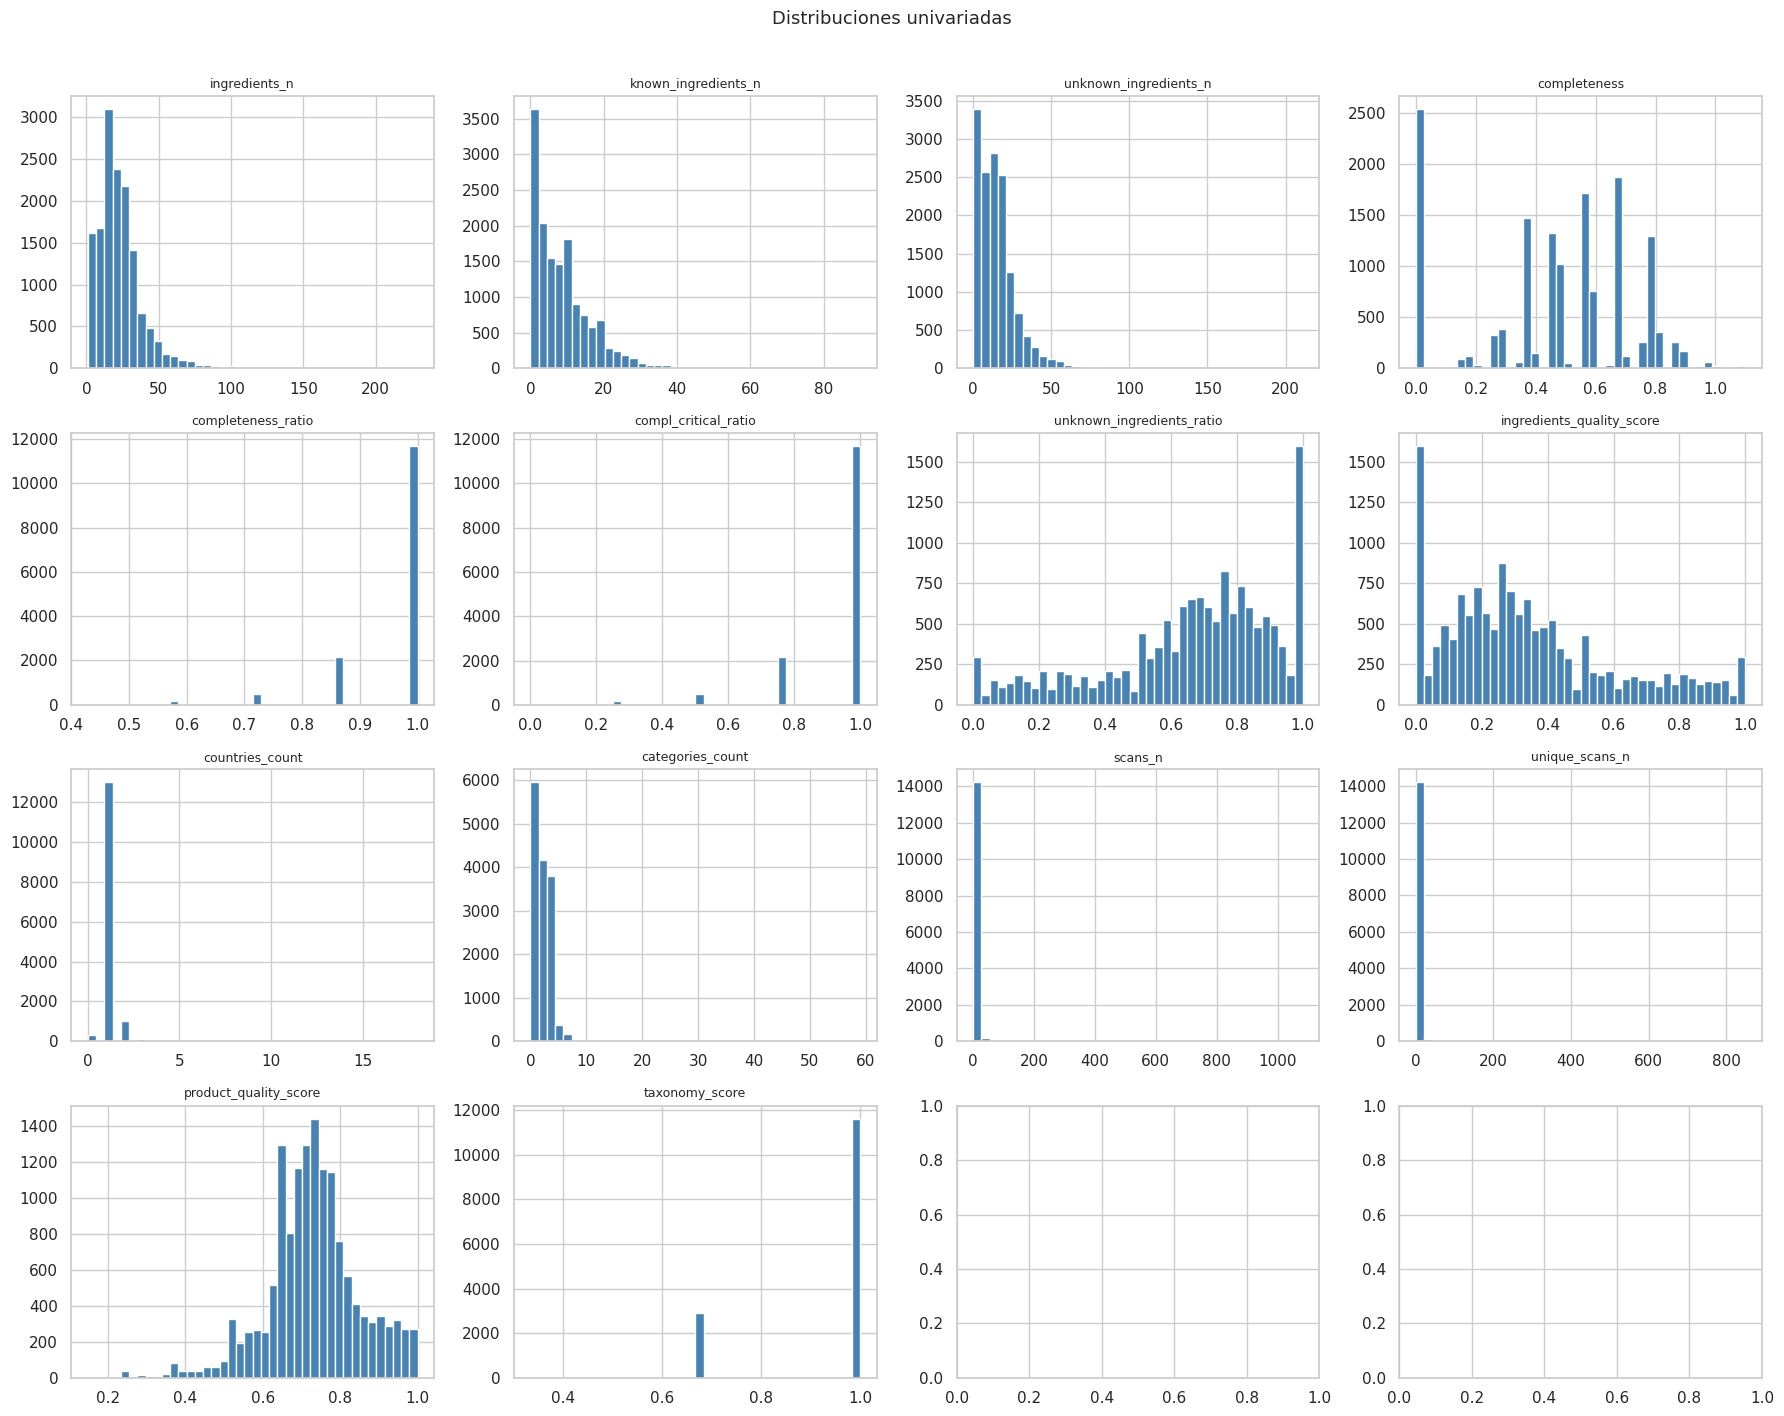

       ingredients_n  known_ingredients_n  unknown_ingredients_n  \
count       14524.00             14524.00               14524.00   
mean           23.05                 8.41                  15.08   
std            16.53                 7.71                  13.07   
min             1.00                 0.00                   0.00   
25%            13.00                 2.00                   6.00   
50%            20.00                 7.00                  13.00   
75%            29.00                12.00                  20.00   
max           229.00                90.00                 211.00   

       completeness  completeness_ratio  compl_critical_ratio  \
count      14524.00            14524.00              14524.00   
mean           0.47                0.96                  0.94   
std            0.27                0.08                  0.14   
min            0.00                0.43                  0.00   
25%            0.36                1.00                  1.00 

In [169]:
# Variables numéricas clave
num_cols = [
    'ingredients_n', 'known_ingredients_n', 'unknown_ingredients_n',
    'completeness', 'completeness_ratio', 'compl_critical_ratio',
    'unknown_ingredients_ratio', 'ingredients_quality_score',
    'countries_count', 'categories_count',
    'scans_n', 'unique_scans_n',
    'product_quality_score', 'taxonomy_score'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='white', color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Distribuciones univariadas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas básicas
print(df[num_cols].describe().round(2))